---

# 🤖 ML 30 — Gradient Descent from Scratch

### **📉 The Algorithm Behind Model Optimization**

---

# 🤖 What is Gradient Descent?

**Gradient Descent** is an optimization algorithm used in Machine Learning to **minimize the loss function** by continuously updating the model's parameters.

## 💡 Simple Intuition

Imagine you're standing on a mountain and want to reach the **lowest point**.

You:

1. Check the slope.
2. Move in the direction of **downhill**.
3. Take a small step.
4. Repeat until you reach the minimum.

In Machine Learning:

**Mountain → Loss Function**
**Position → Model Parameters**
**Downhill → Decreasing Loss**

## ⚙️ Basic Formula

$\theta_{new} = \theta_{old} - \alpha \frac{\partial J}{\partial \theta}$

Where:

* $(\theta)$ = model parameter
* $(\alpha)$ = learning rate
* $(J)$ = loss function
* $(\frac{\partial J}{\partial \theta})$ = gradient

The **learning rate** controls how large each update is.

---

# 🚀 Gradient Descent From Scratch

Before implementing Gradient Descent completely from scratch, let's first understand how the parameters of a linear regression model are updated.

For a simple linear regression model:

$\hat{y} = mx + b$

where:

* $(m)$ → slope / coefficient
* $(b)$ → intercept
* $(\hat{y})$ → predicted value

Our goal is to find the values of $(m)$ and $(b)$ that minimize the prediction error.

## 1. Create a Synthetic Dataset

We will generate a simple regression dataset using Scikit-learn.


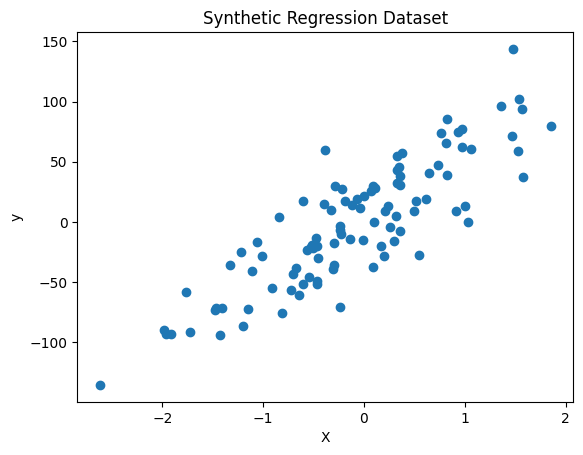

In [1]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=30,
    random_state=42
)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Regression Dataset")
plt.show()

This gives us a dataset with **one input feature** and a continuous target.

---

# 2. Fit Linear Regression Using Scikit-learn

Before implementing Gradient Descent ourselves, let's see what the optimal solution looks like using Scikit-learn's `LinearRegression`.



In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)

In [ ]:
print("Slope (m):", reg.coef_[0])

In [ ]:
print("Intercept (b):", reg.intercept_)



These values give us the best-fitting line according to **Ordinary Least Squares (OLS)**.

Let's visualize it:



In [ ]:
plt.scatter(X, y, label="Data")

plt.plot(
    X,
    reg.predict(X),
    color="red",
    label="OLS Regression Line"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Using OLS")
plt.legend()
plt.show()

---

# 3. Understanding Gradient Descent

Instead of directly calculating the optimal parameters using OLS, we can start with random parameter values and gradually improve them.

Let's assume:

```python
m = 49.82
b = 100
```

The slope is already close to the optimal value, but the intercept is far from its optimal value.

Our initial regression line is therefore:


$\hat{y} = 49.82x + 100$





In [ ]:
m = 49.82
b = 100

y_pred = (m * X + b).ravel()

plt.scatter(X, y, label="Data")

plt.plot(
    X,
    reg.predict(X),
    color="red",
    label="OLS"
)

plt.plot(
    X,
    y_pred,
    label=f"Initial line (b = {b})"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Initial Parameter Values")
plt.legend()
plt.show()

The line is far from the optimal regression line because our intercept $(b)$ is too large.

---

# 4. Gradient Descent for the Intercept

To understand the parameter update more easily, let's first keep the slope constant and update **only the intercept**.

For Mean Squared Error:


$MSE = \frac{1}{n}\sum(y-\hat{y})^2$

The derivative with respect to (b) is:


$\frac{\partial MSE}{\partial b} = -\frac{2}{n}\sum(y-\hat{y})$


For this demonstration, we will use the sum-based gradient:


$\frac{\partial L}{\partial b} = -2\sum(y-\hat{y})$


## Initial values




In [ ]:
m = 49.82
b = 100

y_pred = (m * X.ravel()) + b

loss_slope_b = -2 * np.sum(y - y_pred)

print("Gradient:", loss_slope_b)

The gradient tells us **how the loss changes when we change the intercept**.



---

# 5. Update the Intercept

Gradient Descent updates a parameter using:

$b_{new} = b_{old} - \alpha \frac{\partial L}{\partial b}$

where $(\alpha)$ is the learning rate.



In [ ]:
lr = 0.001

step_size = lr * loss_slope_b
step_size

learning_rate = 0.001

step_size = learning_rate * loss_slope_b

b1 = b - step_size

print("Old b:", b)
print("Gradient:", loss_slope_b)
print("Step size:", step_size)
print("New b:", b1)

The new intercept moves closer to the optimal value.

Let's visualize the update:

In [ ]:
y_pred_initial = m * X.ravel() + b
y_pred_updated = m * X.ravel() + b1

plt.scatter(X, y, label="Data")

plt.plot(
    X,
    reg.predict(X),
    color="red",
    label="OLS"
)

plt.plot(
    X,
    y_pred_initial,
    label=f"Before update (b={b})"
)

plt.plot(
    X,
    y_pred_updated,
    label=f"After update (b={b1:.2f})"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent: First Update")
plt.legend()
plt.show()

---

# 6. Repeating the Process

One update is not enough.

Gradient Descent repeatedly performs:

```text
Calculate Prediction
       ↓
Calculate Gradient
       ↓
Update Parameters
       ↓
Repeat
```

Let's perform multiple iterations while keeping $(m)$ fixed.



In [ ]:
m = 49.82
b = 100

learning_rate = 0.001
epochs = 10

for i in range(epochs):

    y_pred = m * X.ravel() + b

    loss_slope_b = -2 * np.sum(y - y_pred)

    b = b - learning_rate * loss_slope_b

    print(f"Epoch {i+1}: b = {b:.4f}")
    plt.plot(X, y_pred)

plt.scatter(X, y)
plt.show()

Notice how the value of $(b)$ gradually moves toward the optimal intercept.

In [ ]:
m = 49.82
b = 100
lr = 0.001

epochs = 10

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b



In [ ]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

In [ ]:
plt.scatter(X,y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

In [ ]:
print(model.coef_)
print(model.intercept_)

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

---

# 7. Implementing Gradient Descent From Scratch

Now let's move from the manual demonstration to a reusable Python class.

First, we will update **only the intercept**.


In [ ]:
class GDRegressor:

    def __init__(self, learning_rate=0.001, epochs=100):

        self.m = 28.12
        self.b = 100

        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):

        X = X.ravel()

        for i in range(self.epochs):

            y_pred = self.m * X + self.b

            loss_slope_b = -2 * np.sum(y - y_pred)

            self.b = self.b - self.lr * loss_slope_b

        return self

Now let's train it:

In [ ]:
gd = GDRegressor(
    learning_rate=0.001,
    epochs=50
)

gd.fit(X_train, y_train)

print("Learned intercept:", gd.b)

The intercept gradually converges toward the value obtained by the Scikit-learn model.

---

# 8. Updating Both Slope and Intercept

So far, we have only updated $(b)$.

But a linear regression model has **two parameters**:

$\hat{y}=mx+b$

Therefore, we need gradients for both parameters.

### Gradient with respect to $(b)$

$\frac{\partial L}{\partial b} = -2\sum(y-\hat{y})$

### Gradient with respect to $(m)$

$\frac{\partial L}{\partial m} = -2\sum((y-\hat{y})x)$

Now we can update both:

$b = b-\alpha\frac{\partial L}{\partial b}$

$m = m-\alpha\frac{\partial L}{\partial m}$


---

# 9. Complete Gradient Descent Implementation


In [ ]:
class GDRegressor:

    def __init__(self, learning_rate=0.001, epochs=100):

        self.m = 100
        self.b = 100

        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):

        X = X.ravel()

        for i in range(self.epochs):

            # Predictions
            y_pred = self.m * X + self.b

            # Gradients
            loss_slope_b = -2 * np.sum(y - y_pred)
            loss_slope_m = -2 * np.sum((y - y_pred) * X)

            # Parameter updates
            self.b = self.b - self.lr * loss_slope_b
            self.m = self.m - self.lr * loss_slope_m

        return self

    def predict(self, X):

        return self.m * X.ravel() + self.b

---

# 10. Train Our Model

Let's use a fresh synthetic dataset and compare our implementation with Scikit-learn.




In [ ]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=20,
    random_state=13
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

### Scikit-learn Model



In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Scikit-learn slope:", model.coef_[0])
print("Scikit-learn intercept:", model.intercept_)

---

# 11. Train Our Gradient Descent Model



In [ ]:
gd = GDRegressor(
    learning_rate=0.001,
    epochs=50
)

gd.fit(X_train, y_train)

print("Gradient Descent slope:", gd.m)
print("Gradient Descent intercept:", gd.b)

Our parameters should converge very close to the values learned by Scikit-learn.

---

# 12. Compare Predictions


In [ ]:
y_pred_gd = gd.predict(X_test)

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_gd)

print("R² Score:", r2)

We obtained an $(R^2)$ score of approximately:

```text
0.634
```

This is almost identical to the Scikit-learn model:

```text
Scikit-learn R² ≈ 0.635
```

The tiny difference comes from the fact that our Gradient Descent implementation uses a finite number of iterations and a fixed learning rate.


---

# 13. Visual Comparison

Finally, let's compare the regression lines learned by both approaches.

In [ ]:
plt.scatter(X_train, y_train, label="Training Data")

plt.plot(
    X_train,
    model.predict(X_train),
    color="red",
    label="Scikit-learn"
)

plt.plot(
    X_train,
    gd.predict(X_train),
    label="Gradient Descent"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent vs Scikit-learn")
plt.legend()
plt.show()

The two lines should be almost identical.

This demonstrates an important idea:

> **Scikit-learn's `LinearRegression` can find the optimal parameters directly using OLS, while our Gradient Descent implementation starts from initial values and gradually moves toward those parameters.**

---
# 🎯 Conclusion

In this notebook, we implemented **Gradient Descent from scratch** using NumPy and understood how it optimizes model parameters by minimizing the loss function.

## Key Takeaways

* 📉 Gradient Descent minimizes the **cost function** step by step.
* 🎚️ The **learning rate** controls how large each update is.
* 🔄 Parameters are repeatedly updated until the model converges.
* 🧠 Implementing it from scratch helps us understand what happens behind `model.fit()`.

**Gradient Descent is one of the most important optimization algorithms in Machine Learning and Deep Learning.**
